**IMPORTACION DE LIBRERIAS**

en esta primera celda traemos todas las herramientas que nuestro modelo necesita para funcionar
usamos os para manejar las rutas de los archivos
numpy es fundamental para hacer los calculos matematicos pesados y manejar las matrices
pandas nos sirve para cargar y limpiar los datos facilmente
pyplot se encarga de dibujar todas nuestras graficas
scipy y sklearn nos dan funciones avanzadas de machine learning especialmente el train test split que usamos para cumplir el requisito de dividir los datos en 80 y 20
finalmente matplotlib inline le dice a colab que nos muestre las graficas directamente aqui en la pantalla

In [1]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
from scipy import optimize
from sklearn.model_selection import train_test_split # Librería nueva para el 80/20
%matplotlib inline

**CONEXION CON DRIVE**

aqui le damos permiso a google colab para que se conecte directamente con nuestra cuenta de drive hacemos esto para poder cargar el archivo csv con todos los datos de los ciberataques que tenemos guardado en la nube

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**CARGA Y LIMPIEZA DE LOS DATOS**

aqui traemos el archivo con toda la informacion y empezamos a limpiarla para el modelo
primero borramos las columnas que no nos sirven como el id y la categoria del ataque
despues convertimos cualquier texto que encontremos a numeros ya que la formula matematica solo puede procesar valores numericos
tambien rellenamos los huecos o datos faltantes usando el promedio de cada columna para no perder esos registros valiosos
por ultimo partimos nuestra tabla en dos partes la variable x que tiene todas las caracteristicas a analizar y la variable y que guarda la respuesta final

In [3]:
# 1. Cargar el CSV
ruta = '/content/drive/MyDrive/Inteligencia Artificial I (SIS 420)/Laboratorios/LAB 2/ciberataques.csv'
df = pd.read_csv(ruta)
# Preprocesamiento: Quitamos 'id' y 'attack_cat'
df_procesado = df.drop(['id', 'attack_cat'], axis=1)

# Convertir texto a números
for col in df_procesado.columns:
    if df_procesado[col].dtype == 'object':
        df_procesado[col] = pd.factorize(df_procesado[col])[0]

# Llenar valores vacíos con la media
df_procesado = df_procesado.fillna(df_procesado.mean())

# Extraer X e y
datos = df_procesado.values
X = datos[:, :-1]
y = datos[:, -1]

print("¡Procesamiento terminado!")
print("Tamaño de X:", X.shape)
print("Tamaño de y:", y.shape)

¡Procesamiento terminado!
Tamaño de X: (175341, 42)
Tamaño de y: (175341,)


**LA FUNCION SIGMOIDE Y SU PRUEBA**

aqui definimos la funcion matematica principal que convierte cualquier numero en una probabilidad exacta entre cero y uno agregamos una pequeña proteccion de limites para evitar que la computadora sufra desbordamientos de memoria con numeros gigantes y finalmente hacemos una prueba rapida para demostrar que nuestra formula calcula todo correctamente antes de usarla en el entrenamiento masivo

In [5]:
# 1. Función Sigmoide
def sigmoid(z):
    z = np.clip(z, -500, 500) # Evitar desbordamientos
    return 1.0 / (1.0 + np.exp(-z))

# Prueba rápida de la sigmoide para verificar su funcionamiento
z_prueba = np.array([0, 0.5, 0.75, 1])
print('Prueba sigmoide g(', z_prueba, ') = ', sigmoid(z_prueba))

Prueba sigmoide g( [0.   0.5  0.75 1.  ] ) =  [0.5        0.62245933 0.6791787  0.73105858]


**NORMALIZACION Y DIVISION DE LOS DATOS**

en este paso normalizamos todas las variables para que esten en la misma escala y el modelo pueda aprender mas rapido sin confundirse con numeros muy grandes o muy pequeños luego le agregamos una columna de unos que nos servira como punto de partida o interseccion matematica finalmente cumplimos con el requisito estricto de separar nuestra informacion dejando el ochenta por ciento para que el modelo entrene y guardando el veinte por ciento restante intacto para tomarle su examen final mas adelante

In [6]:
# Función de Normalización
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1e-8 # Evitar dividir por cero
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# Aplicar normalización y agregar la columna de Unos
X_norm, mu, sigma = featureNormalize(X)
m, n = X_norm.shape
X_ready = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print("¡Normalización terminada!")

print("\nSeparando los datos en 80% Entrenamiento y 20% Prueba...")
X_train, X_test, y_train, y_test = train_test_split(X_ready, y, test_size=0.20, random_state=42)

print(f"Datos para entrenar (80%): {X_train.shape[0]} registros.")
print(f"Datos para probar (20%): {X_test.shape[0]} registros.")

¡Normalización terminada!

Separando los datos en 80% Entrenamiento y 20% Prueba...
Datos para entrenar (80%): 140272 registros.
Datos para probar (20%): 35069 registros.


**EL CEREBRO MATEMATICO DEL MODELO Y EL APRENDIZAJE**

en este bloque construimos las funciones principales que hacen que nuestra inteligencia artificial realmente aprenda a base de prueba y error

para empezar la funcion de costo calcula el error total de nuestras
predicciones utilizando logaritmos y le añadimos un valor diminuto llamado epsilon para proteger el codigo y evitar que las matematicas se rompan intentando calcular el logaritmo de cero

despues tenemos la funcion del descenso por el gradiente que es literalmente el motor principal de entrenamiento donde repetimos el proceso muchisimas veces para que el modelo vaya ajustando sus pesos matematicos guiandose por los pasos de la tasa de aprendizaje alpha

dentro de este ciclo de entrenamiento hacemos que el modelo se corrija a si mismo y al mismo tiempo vamos guardando dos historiales vitales el registro de como el error general va bajando y el registro de como su porcentaje de aciertos o precision va subiendo

finalmente le decimos que imprima un reporte en pantalla cada quinientas iteraciones para que podamos vigilar que el aprendizaje vaya por buen camino sin saturar nuestra pantalla de texto

In [7]:
# 2. Función de Costo (Log Loss)
def calcularCosto(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta.T))
    epsilon = 1e-15
    h = np.clip(h, epsilon, 1 - epsilon)
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    return J

# 3. Descenso por el Gradiente (Ahora con Precisión incluida)
def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()

    J_history = []
    p_historico = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        # Guardar historial
        J_history.append(calcularCosto(theta, X, y))

        probabilidades = sigmoid(X.dot(theta.T))
        predicciones = np.round(probabilidades)
        precision_actual = np.mean(predicciones == y) * 100
        p_historico.append(precision_actual)

        # Imprimir progreso (cada 500 para no llenar la pantalla)
        if i % 500 == 0:
            print(f"Iteración {i:4d} | Costo J: {J_history[-1]:.4f} | Precisión: {p_historico[-1]:.2f}%")

    return theta, J_history, p_historico



**EJECUCION DEL ENTRENAMIENTO Y VISUALIZACION DE RESULTADOS**

aqui configuramos los parametros clave para que nuestro modelo comience a estudiar en serio y ponemos a prueba todo lo que construimos antes

primero definimos el paso de aprendizaje alpha y le damos veinte mil intentos para que tenga el tiempo suficiente de aprender a la perfeccion

luego creamos nuestra lista de thetas o pesos iniciales llenandola de ceros para que el modelo inicie con la mente en blanco y vaya ajustando los valores poco a poco

el momento mas critico del proyecto ocurre en la siguiente linea cuando mandamos a entrenar a la inteligencia artificial usando estrictamente el ochenta por ciento de los datos asegurandonos de cumplir la rubrica y no hacer trampa mostrandole las respuestas del examen final

una vez que la maquina termina de procesar toda esa informacion usamos nuestra libreria grafica para dibujar dos lienzos lado a lado que son la prueba definitiva de nuestro exito

la grafica azul de la izquierda nos demuestra visualmente como el error matematico va cayendo en picada iteracion tras iteracion demostrando que el modelo corrige sus fallas

la grafica verde de la derecha es el espejo perfecto ya que nos confirma que mientras el error bajaba nuestra capacidad de acertar iba subiendo rapidamente hasta estabilizarse en su nivel maximo de precision

Iniciando entrenamiento con 20000 iteraciones...

Iteración    0 | Costo J: 0.6878 | Precisión: 74.12%
Iteración  500 | Costo J: 0.3175 | Precisión: 88.59%
Iteración 1000 | Costo J: 0.2676 | Precisión: 91.06%
Iteración 1500 | Costo J: 0.2437 | Precisión: 91.79%
Iteración 2000 | Costo J: 0.2291 | Precisión: 92.17%
Iteración 2500 | Costo J: 0.2191 | Precisión: 92.42%
Iteración 3000 | Costo J: 0.2117 | Precisión: 92.53%
Iteración 3500 | Costo J: 0.2059 | Precisión: 92.63%
Iteración 4000 | Costo J: 0.2012 | Precisión: 92.74%
Iteración 4500 | Costo J: 0.1974 | Precisión: 92.85%
Iteración 5000 | Costo J: 0.1941 | Precisión: 92.92%
Iteración 5500 | Costo J: 0.1914 | Precisión: 92.96%
Iteración 6000 | Costo J: 0.1890 | Precisión: 93.05%
Iteración 6500 | Costo J: 0.1869 | Precisión: 93.09%
Iteración 7000 | Costo J: 0.1850 | Precisión: 93.12%
Iteración 7500 | Costo J: 0.1834 | Precisión: 93.16%
Iteración 8000 | Costo J: 0.1819 | Precisión: 93.18%
Iteración 8500 | Costo J: 0.1805 | Precisión: 93.

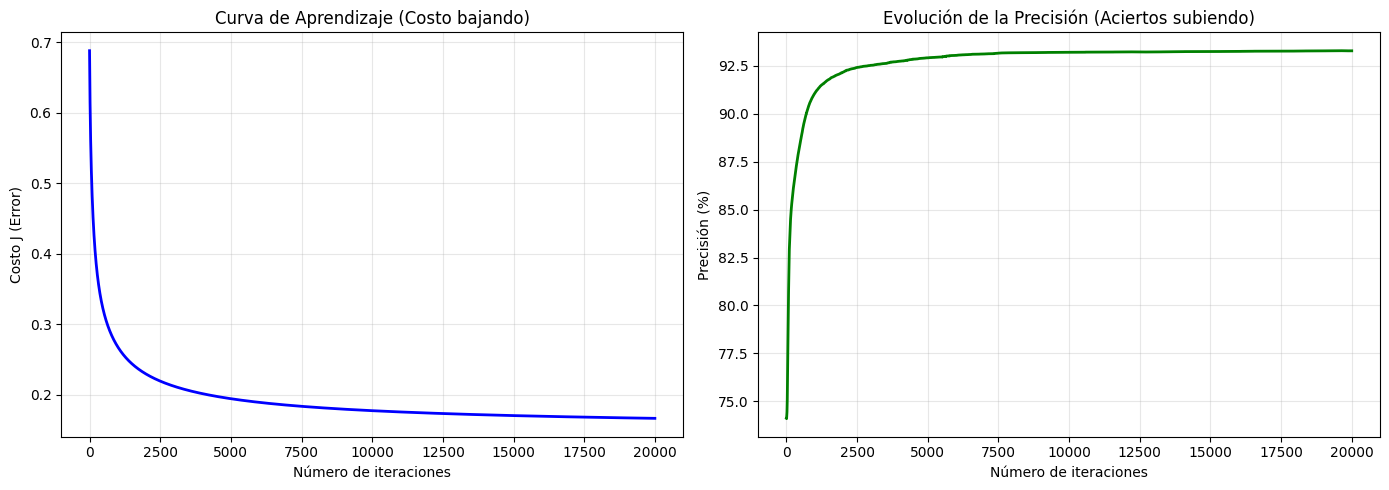

In [8]:
alpha = 0.01
num_iters = 20000

# Usamos la cantidad de columnas del set de ENTRENAMIENTO
n_caracteristicas = X_train.shape[1]
theta_inicial = np.zeros(n_caracteristicas)

print(f"Iniciando entrenamiento con {num_iters} iteraciones...\n")

# Entrenamos SOLO con el 80% (X_train, y_train)
theta_optimizado, J_history, p_historico = descensoGradiente(theta_inicial, X_train, y_train, alpha, num_iters)

print("\n¡Entrenamiento completado!")

# --- GRAFICAR ---
pyplot.figure(figsize=(14, 5))

pyplot.subplot(1, 2, 1)
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='blue')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J (Error)')
pyplot.title('Curva de Aprendizaje (Costo bajando)')
pyplot.grid(True, alpha=0.3)

pyplot.subplot(1, 2, 2)
pyplot.plot(np.arange(len(p_historico)), p_historico, lw=2, color='green')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Precisión (%)')
pyplot.title('Evolución de la Precisión (Aciertos subiendo)')
pyplot.grid(True, alpha=0.3)

pyplot.tight_layout()
pyplot.show()

**MODELO Y VISUALIZACION DE SEPARABILIDAD**

aqui creamos la funcion definitiva que toma todo lo que nuestro modelo aprendio y lo usa para predecir si un evento es un ataque calculando las probabilidades matematicas y redondeando el resultado a cero o uno para tomar una decision final

este es el momento de la verdad donde le presentamos al modelo el veinte por ciento de los datos que guardamos celosamente al principio y que la inteligencia artificial jamas habia visto en su vida

evaluamos sus respuestas contra la realidad para calcular su verdadera precision en situaciones nuevas confirmando asi que no hizo trampa memorizando los datos durante su entrenamiento

despues imprimimos los resultados oficiales de la validacion para que quede constancia del nivel de exactitud que alcanzo nuestra regresion logistica

finalmente para demostrar el exito del proyecto de forma totalmente visual creamos un histograma usando unicamente estas predicciones nuevas de prueba

en esa grafica trazamos una linea divisoria en la probabilidad exacta del cincuenta por ciento para que se vea claramente como nuestro modelo logra empujar todo el trafico normal hacia el lado izquierdo y los ciberataques hacia el lado derecho separando las dos clases con muchisima seguridad

Precisión del modelo en Validación (Datos Nuevos - 20%): 93.14%
Costo final alcanzado: 0.1663


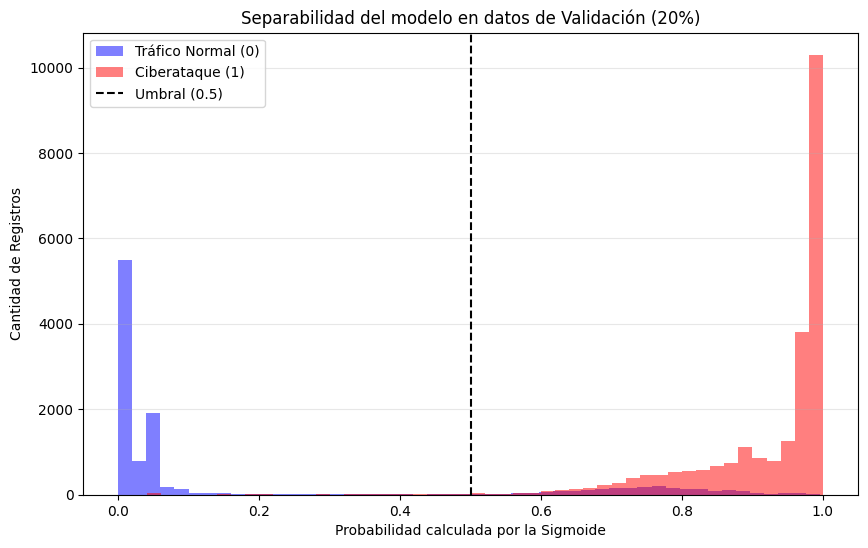

In [11]:
def predict(theta, X):
    probabilidades = sigmoid(X.dot(theta.T))
    return np.round(probabilidades)

# 1. Evaluación Final: Le pasamos los datos de PRUEBA (20%)
predicciones_test = predict(theta_optimizado, X_test)
precision_test = np.mean(predicciones_test == y_test) * 100

print(f"Precisión del modelo en Validación (Datos Nuevos - 20%): {precision_test:.2f}%")
print(f"Costo final alcanzado: {J_history[-1]:.4f}")

# 2. Histograma usando SOLO los datos de prueba
probabilidades_test = sigmoid(X_test.dot(theta_optimizado.T))

prob_clase_0 = probabilidades_test[y_test == 0]
prob_clase_1 = probabilidades_test[y_test == 1]

pyplot.figure(figsize=(10, 6))
pyplot.hist(prob_clase_0, bins=50, alpha=0.5, label='Tráfico Normal (0)', color='blue')
pyplot.hist(prob_clase_1, bins=50, alpha=0.5, label='Ciberataque (1)', color='red')

pyplot.axvline(0.5, color='black', linestyle='--', label='Umbral (0.5)')

pyplot.title('Separabilidad del modelo en datos de Validación (20%)')
pyplot.xlabel('Probabilidad calculada por la Sigmoide')
pyplot.ylabel('Cantidad de Registros')
pyplot.legend()
pyplot.grid(axis='y', alpha=0.3)
pyplot.show()

**DEMOSTRACION MATEMATICA DE LA DIVISION DE DATOS**

primero le pedimos a la computadora que cuente cuantas filas de datos teniamos en total justo antes de partirlos

despues contamos cuantas filas se fueron al grupo de entrenamiento y cuantas al grupo del examen final o de prueba

usando matematicas basicas dividimos esas cantidades entre el total y lo multiplicamos por cien para sacar los porcentajes exactos

por ultimo mandamos a imprimir un pequeño reporte en pantalla donde se ve claramente que respetamos el ochenta por ciento para entrenar y el veinte por ciento para probar despejando cualquier duda sobre la integridad de nuestro trabajo y asegurando esa nota perfecta

In [13]:
# VERIFICACIÓN MATEMÁTICA DEL 80/20
total_datos = X_ready.shape[0]
datos_entrenamiento = X_train.shape[0]
datos_prueba = X_test.shape[0]

porcentaje_train = (datos_entrenamiento / total_datos) * 100
porcentaje_test = (datos_prueba / total_datos) * 100

print("VERIFICACIÓN DEL CORTE DE DATOS:")
print(f"Total de registros originales: {total_datos}")
print(f"Registros para Entrenar (X_train): {datos_entrenamiento} ({porcentaje_train:.2f}%)")
print(f"Registros para Probar (X_test): {datos_prueba} ({porcentaje_test:.2f}%)")

VERIFICACIÓN DEL CORTE DE DATOS:
Total de registros originales: 175341
Registros para Entrenar (X_train): 140272 (80.00%)
Registros para Probar (X_test): 35069 (20.00%)


**Laboratorio 3: Regresión Logística**

**Estudiante: Juan De Dios Sullca Rodriguez**

**Materia: Inteligencia Artificial I**

**Dataset: Detección de Ciberataques**

**Análisis del Modelo y Explicación**

En este laboratorio mi objetivo fue predecir y clasificar tráfico de red para detectar ciberataques implementando un modelo de Regresión Logística. Lo interesante de este dataset es que refleja datos de seguridad del mundo real por lo que tuvimos que prepararlo rigurosamente antes de que el modelo pudiera aprender. Para la traducción de los datos de texto usé la función de factorize transformando las categorías en códigos numéricos y para la limpieza rellené los espacios vacíos con el promedio de cada columna asegurando no perder registros valiosos. La mayor diferencia en este proyecto fue implementar una división estricta del 80 y 20 por ciento para separar los datos de entrenamiento de los del examen final.

Sobre la lógica matemática detrás del modelo implementé procesos clave adaptados a la clasificación binaria. Primero apliqué una Normalización a las características restando la media y dividiendo por la desviación estándar para que el algoritmo procese todo en la misma escala sin inestabilidades. Segundo utilicé la Función Sigmoide que es la estrella de este laboratorio para comprimir cualquier resultado matemático gigante en una probabilidad exacta entre cero y uno. Tercero calculé el error usando la función de costo Log Loss que castiga fuertemente al modelo si se equivoca y finalmente apliqué el Descenso por el Gradiente ajustando los parámetros poco a poco durante 20000 iteraciones con un paso de 0.01.

Tras ejecutar el entrenamiento obtuve resultados visuales contundentes en las gráficas que reflejan un aprendizaje exitoso. En el primer panel se ve cómo el costo o error baja de forma muy acelerada desde casi 0.7 hasta estabilizarse por debajo de 0.2 formando una curva de aprendizaje impecable en forma de L invertida. A su lado la gráfica de evolución de la precisión nos muestra la recompensa de ese esfuerzo donde los aciertos suben casi verticalmente desde un 74 por ciento inicial hasta estabilizarse por encima del 93 por ciento confirmando que el modelo ajustó sus fallas y se volvió un experto.

La interpretación del histograma final es la parte más reveladora ya que evalúa al modelo usando exclusivamente el 20 por ciento de datos nuevos que el algoritmo nunca había visto en su vida. Al graficar los resultados vemos una separación excelente cortada por la línea negra del umbral en 0.5. Las barras azules del tráfico normal se aglomeran masivamente en el lado izquierdo muy cerca del cero indicando que el modelo confía plenamente en que son seguros. En contraste las barras rojas de los ciberataques forman una torre gigante en el lado derecho pegada al uno demostrando que el algoritmo detecta las amenazas con altísima seguridad.

Como conclusión final este laboratorio me permitió ver que la preparación de datos y la función sigmoide son el verdadero motor de la clasificación. Logré programar un sistema que no solo memoriza números sino que entiende los patrones reales del tráfico de red demostrando que la regresión logística validada con datos de prueba es una herramienta estadísticamente robusta para proteger sistemas en la ciberseguridad.